In [ ]:
import numpy as np
import cv2
from scipy.ndimage import shift
import matplotlib.pyplot as plt
import tifffile
import os
from tqdm import tqdm
from czifile import CziFile

def estimate_shift(image, max_shift=2):
    """Estimate the shift between odd and even lines using cross-correlation with constraints."""
    h, w = image.shape
    shifts = []
    
    for y in range(1, h, 2):  # Process every odd line
        even_line = image[y - 1, :]
        odd_line = image[y, :]
        
        # Compute normalized cross-correlation
        correlation = np.correlate(even_line - even_line.mean(), odd_line - odd_line.mean(), mode='full')
        shift_range = len(correlation) // 2
        
        # Limit shift search to a reasonable range
        valid_range = (shift_range - max_shift, shift_range + max_shift)
        shift_est = np.argmax(correlation[valid_range[0]:valid_range[1]]) + valid_range[0] - shift_range
        shifts.append(shift_est)
    
    # Remove outliers using median absolute deviation (MAD)
    print(shifts)
    median_shift = np.median(shifts)
    mad = np.median(np.abs(shifts - median_shift))
    filtered_shifts = [s for s in shifts if abs(s - median_shift) < 3 * mad]
    
    return np.median(filtered_shifts) if filtered_shifts else median_shift  # Use robust shift estimate

def correct_image(image, shift_value):
    """Apply the estimated shift correction to every odd line."""
    corrected_image = np.copy(image)
    h, w = image.shape
    
    for y in range(1, h, 2):  # Apply correction to odd lines
        corrected_image[y, :] = shift(image[y, :], shift_value, mode='nearest')
    
    return corrected_image

def correct_bidirectional_scan(image_stack):
    """Correct a 4-channel bidirectional line scan image."""
    corrected_stack = np.copy(image_stack)
    
    # Extract the last channel (assumed strongest)
    ref_channel = image_stack[-1, :, :]
    shift_value = estimate_shift(ref_channel)
    print()
    print(f"Estimated shift: {shift_value:.2f} pixels (filtered)")
    
    # Apply correction to all channels
    for c in range(4):
        corrected_stack[c, :, :] = correct_image(image_stack[c, :, :], shift_value)
    
    return corrected_stack

def correction_process_all_2D_czi_folders(root_folder, output_dir):
    """Wrapper function to process all subfolders and nested subfolders containing .czi files."""
    for root, dirs, files in os.walk(root_folder):
        if any(file.endswith(".czi") for file in files):
            relative_path = os.path.relpath(root, root_folder)
            output_subdir = os.path.join(output_dir, relative_path)
            print(f"Processing folder: {root} -> {output_subdir}")
            correction_process_czi_folder(root, output_subdir)
    
    print("All folders processed!")

def correction_process_czi_folder(czi_folder, output_dir):
    """Process .czi files from a folder, do correction, and save all new images."""
    os.makedirs(output_dir, exist_ok=True)
    
    for file_name in tqdm(os.listdir(czi_folder)):
        if file_name.endswith(".czi"):
            with CziFile(os.path.join(czi_folder, file_name)) as czi:
                img_data = np.squeeze(czi.asarray()) 
                # corrected_image = correct_bidirectional_scan(img_data)
                corrected_image = correct_image(img_data, -1)
                base_name = os.path.splitext(os.path.basename(file_name))[0]
                output_path = os.path.join(output_dir, f"{base_name}_correction.tiff")
                tifffile.imwrite(
                          output_path,
                          corrected_image,
                          imagej=True,    
                          metadata={'axes': 'CYX'},
                      )

data_folder = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/eGFP-Zyxin-488_Phalloidin-405_Vinculin-rb0-647_pPaxy31-m-568/Control'
output_dir = '/mnt/d/lding/FA/processed_data/FA_ML_Annabel_20250217_correction/eGFP-Zyxin-488_Phalloidin-405_Vinculin-rb0-647_pPaxy31-m-568/Control_again'
os.makedirs(output_dir,exist_ok=True)
correction_process_all_2D_czi_folders(data_folder, output_dir)


Processing folder: /mnt/d/lding/FA/data/FA_ML_Annabel_20250217/eGFP-Zyxin-488_Phalloidin-405_Vinculin-rb0-647_pPaxy31-m-568/Control -> /mnt/d/lding/FA/processed_data/FA_ML_Annabel_20250217_correction/eGFP-Zyxin-488_Phalloidin-405_Vinculin-rb0-647_pPaxy31-m-568/Control_again/.


  0%|          | 0/11 [00:00<?, ?it/s]


ValueError: too many values to unpack (expected 2)

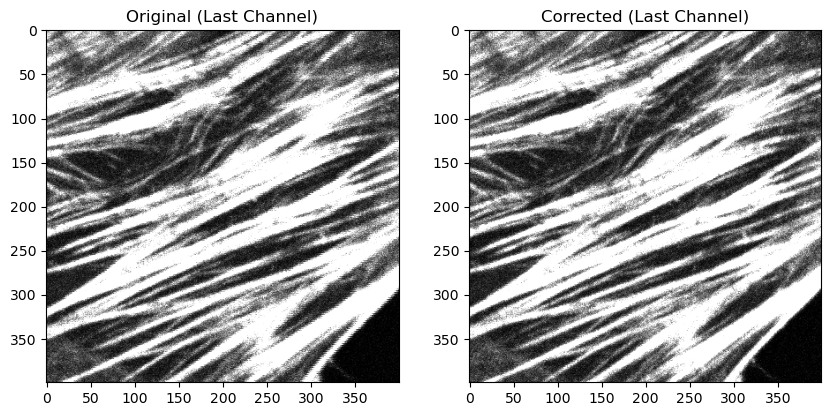

In [16]:
import czifile
import tifffile
sample_image = np.squeeze(czifile.imread('/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/eGFP-Zyxin-488_Phalloidin-405_Vinculin-rb0-647_pPaxy31-m-568/Control/eGFP-Zyxin 488, Phalloidin 405, Vinculin(rb0) 647, pPaxy31(m)568_control-01.czi'))

corrected_image = sample_image.copy()
# corrected_image = correct_bidirectional_scan(sample_image)
# corrected_image = correct_image(sample_image,-1)
for c in range(4):
        corrected_image[c, :, :] = correct_image(sample_image[c, :, :], -2)
    

tifffile.imwrite(
    '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/eGFP-Zyxin-488_Phalloidin-405_Vinculin-rb0-647_pPaxy31-m-568/Control_correction/eGFP-Zyxin 488, Phalloidin 405, Vinculin(rb0) 647, pPaxy31(m)568_control-01_correction.tiff',
    corrected_image,
    imagej=True,    
    metadata={'axes': 'CYX'},
)


# Display before and after
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_image[-1, 800:1200, 800:1200,], cmap='gray')
plt.title("Original (Last Channel)")

plt.subplot(1, 2, 2)
plt.imshow(corrected_image[-1, 800:1200, 800:1200,], cmap='gray')
plt.title("Corrected (Last Channel)")
plt.show()


In [ ]:
corrected_image.shape